In [35]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [36]:
# ETAPA 1: Cargar y explorar el dataset
X_pos224 = np.load('X_SES_COVID_POSITIVE_224_Normal.npy')
print(X_pos224.shape) 
# 2604 imagenes
# cada umagen mide 224x224
print(X_pos224)

(2604, 224, 224)
[[[    0     0     0 ... 13667 14126 14441]
  [    0     0     0 ... 13353 13701 13895]
  [    0     0     0 ... 13111 13305 13745]
  ...
  [ 2702  2968  3357 ...     0     0     0]
  [ 2649  2859  3381 ...     0     0     0]
  [ 2391  3023  3402 ...     0     0     0]]

 [[    0     0     0 ...     0     0     0]
  [    0     0     0 ...     0     0     0]
  [    0     0     0 ...     0     0     0]
  ...
  [    0     0     0 ...     0     0     0]
  [    0     0     0 ...     0     0     0]
  [    0     0     0 ...     0     0     0]]

 [[    0     0     0 ...     0     0     0]
  [    0     0     0 ...     0     0     0]
  [    0     0     0 ...     0     0     0]
  ...
  [    0     0     0 ... 11959 11732 11539]
  [    0     0     0 ... 11659 11691 11390]
  [    0     0     0 ... 11698 11777 11257]]

 ...

 [[    0     1    61 ...     0     0     0]
  [    0     0    40 ...     0     0     0]
  [    0     0    31 ...     0     0     0]
  ...
  [    0     0     0 ..

In [37]:
#X_pos600 = np.load('X_SES_COVID_POSITIVE_600_Normal.npy')
#print(X_pos600.shape)
# 2600 imagenes
# cada imagen mide 600x600
#print(X_pos600)

In [38]:
# contar imagenes
num_pos224 = X_pos224.shape[0]
num_pos224

2604

In [39]:
# verificar tamaño de la imagen
print(X_pos224[0].shape)

(224, 224)


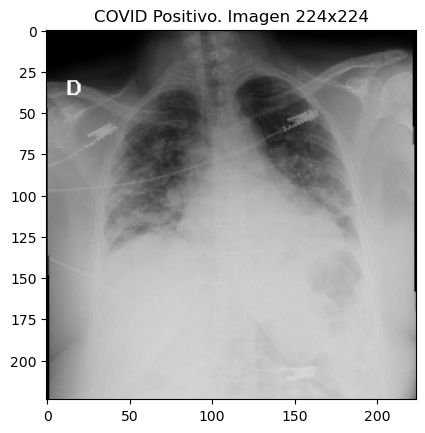

In [40]:
# mostrar imagenes 224x224
plt.imshow(X_pos224[100], cmap='grey')
plt.title('COVID Positivo. Imagen 224x224')
#plt.axis('off')
plt.show()

In [41]:
# mostrar imagenes 600x600
#plt.imshow(X_pos600[0], cmap='grey')
#plt.title('COVID Positivo. Imagen 600x600')
#plt.axis('off')
#plt.show()

In [42]:
# vamos a trabajar con la version 224x224 px para reduir el costo computacional de las 
# etapas de vectorizacion.
X_neg224 = np.load("X_SES_COVID_NEGATIVE_224_Normal.npy")
print(X_neg224.shape)
print(X_neg224)

(1987, 224, 224)
[[[  868   513   351 ...   186   344   699]
  [  665   409   241 ...   149   310   670]
  [  589   343   194 ...   145   280   624]
  ...
  [10474  6502  3257 ... 11900 12520 12692]
  [12385 10624  6624 ... 13224 13373 13280]
  [11953 12306 10758 ... 13056 12939 12906]]

 [[    0    10     9 ...    51    55    45]
  [    0    11     7 ...    33    32    31]
  [    0     6     6 ...    21    21    18]
  ...
  [   13     7     7 ...     3     3     0]
  [   14     7     7 ...     4     4     0]
  [   10     7     8 ...     4     4     0]]

 [[   45    19    12 ...    19    11     0]
  [   56    27    12 ...    70    70     0]
  [   63    26    13 ...    95    84     0]
  ...
  [    0 10103  9326 ...  9113  8967  8638]
  [    0 10306  9545 ...  9784  9754  9184]
  [    0 10471  9935 ... 10502 10548 10077]]

 ...

 [[    1     1     1 ...   197   226   198]
  [    1     1     1 ...   212   188   214]
  [    1     1     1 ...  1073   352   193]
  ...
  [   79    89   138 ..

In [43]:
# contar imagenes
num_neg224 = X_neg224.shape[0]
num_neg224

1987

In [44]:
# verificar tamaño de la imagen
print(X_pos224[0].shape)

(224, 224)


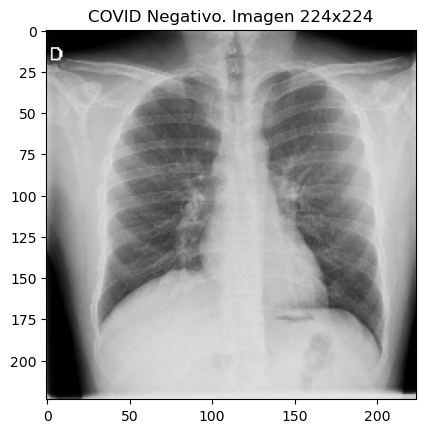

In [45]:
# mostrar imagenes 224x224
plt.imshow(X_neg224[0], cmap='grey')
plt.title('COVID Negativo. Imagen 224x224')
#plt.axis('off')
plt.show()

In [46]:
# unir todo el dataset
x_pos = np.ones(X_pos224.shape[0])
x_neg = np.zeros(X_neg224.shape[0])

In [47]:
x = np.concatenate((X_pos224, X_neg224))
y = np.concatenate((x_pos, x_neg))

In [48]:
x.shape

(4591, 224, 224)

In [49]:
y.shape

(4591,)

In [50]:
# verificar distribucion de clases
df = pd.DataFrame({
    "label":y
})

print(df["label"].value_counts())
# imagenes COVID+ 2604
# imagenes COVID- 1987

# Total 4591
# tamaño de imagen 224x224

label
1.0    2604
0.0    1987
Name: count, dtype: int64


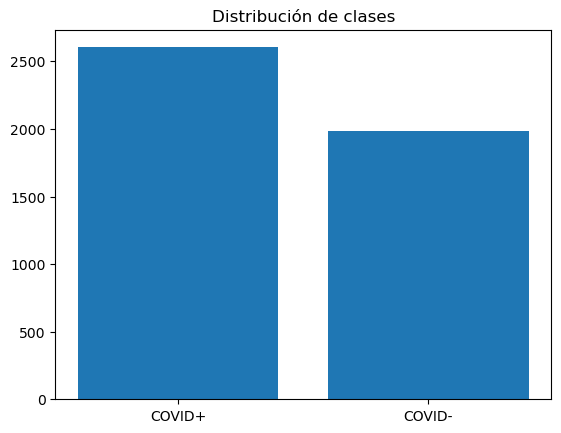

In [51]:
plt.bar(["COVID+","COVID-"], [num_pos224,num_neg224])
plt.title("Distribución de clases")
plt.show()

In [52]:
print(x.dtype) # cada pixel esta almacenado en 16 bits sin signo (vint16)
print(x.shape) # 4591 radiografias donde c/u mide 224x224 px
print(x.min()) # los niveles de gris van de 0 a 16383 (14 bits efectivos)
print(x.max())

uint16
(4591, 224, 224)
0
16383


In [53]:
# ETAPA 2: Preprocesamiento
# PARTE A: normalizar
# para que las variables queden en la misma escala, algo fundamental para PCA y SVD
X_procesado = x.astype(np.float32) / 16383.0

In [54]:
print(X_procesado.min())
print(X_procesado.max())

0.0
1.0


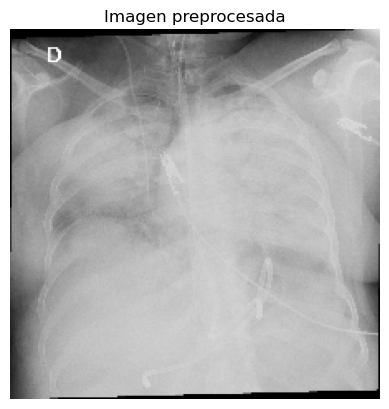

In [55]:
plt.imshow(X_procesado[0], cmap="gray")
plt.title("Imagen preprocesada")
plt.axis("off")
plt.show()

In [56]:
# PARTE B: Redimensionamiento
# verificamos
X_vectores = X_procesado.reshape(X_procesado.shape[0],-1)
X_vectores.shape

(4591, 50176)

In [57]:
pip install opencv-python

Note: you may need to restart the kernel to use updated packages.


In [58]:
import cv2
# Yo avanzaría a la ETAPA 3 sin redimensionar 
# y evaluaría el rendimiento (si mi compu soporta la matriz 224x244) 
# antes de reducir resolución.
x.shape
# se redimensiona individualmente

# METODO 2: lISTA COMPREHENSION

"""
# METODO 1: USAMOS EL BUCLE FOR
import numpy as np
X_redimensionado = []

for img in X_procesado:
    nuevo_img = cv2.resize(img, (128,128))
    X_redimensionado.append(nueva_img)
X_redimensionado = np.array(X_redimensionado)
print(X_redimensionado.shape)
"""
X_redimensionado = np.array([
    cv2.resize(img, (128,128))
    for img in X_procesado
])
print(X_redimensionado.shape)


(4591, 128, 128)


In [61]:
# ETAPA 3: vectorizar

# REDIMENSIONADO
X_vectores = X_redimensionado.reshape(
    X_redimensionado.shape[0],
    -1
)
"""
# SIN REDIMENSIONAR
X_vectores = X_procesado.reshape(
    X_procesado.shape[0],-1)

"""
X_vectores.shape 
# 4591 -> cada fila es una radiografia
# 50176 -> un pixel por caracteristica
# cada imagen fue tranformada de una matriz 224 x224 a un vector 50176 x 1


(4591, 16384)

In [62]:
# ETAPA 4: División entrenamiento/prueba
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_vectores,
    y,
    test_size=0.2,      # 20% para prueba, 80% para entrenamiento
    stratify=y,         # mantiene la misma proporción de COVID+/COVID- en ambos conjuntos
    random_state=42     # semilla fija, para que el resultado sea reproducible
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (3672, 16384)
X_test: (919, 16384)
y_train: (3672,)
y_test: (919,)


In [63]:
# ETAPA 5: PCA usando SVD
from sklearn.decomposition import PCA

pca = PCA(n_components=50, random_state=42)

# El PCA se "ajusta" (fit) SOLO con datos de entrenamiento
X_train_pca = pca.fit_transform(X_train)

# Al test set solo se le aplica la transformación ya aprendida (transform, no fit)
X_test_pca = pca.transform(X_test)

print("Antes:", X_train.shape)
print("Después:", X_train_pca.shape)

# Cuánta información (varianza) se conserva con 50 componentes
print("Varianza explicada total:", pca.explained_variance_ratio_.sum())

Antes: (3672, 16384)
Después: (3672, 50)
Varianza explicada total: 0.9337667


In [64]:
# ETAPA 6: Geometría Computacional

# Paso 1: separar las imágenes de entrenamiento por clase
covid_pos = X_train_pca[y_train == 1]
covid_neg = X_train_pca[y_train == 0]

print("Cantidad COVID+ en train:", covid_pos.shape[0])
print("Cantidad COVID- en train:", covid_neg.shape[0])

# Paso 2: calcular el centroide (promedio) de cada clase
centroide_pos = np.mean(covid_pos, axis=0)
centroide_neg = np.mean(covid_neg, axis=0)

print("Centroide COVID+:", centroide_pos.shape)  # (50,)
print("Centroide COVID-:", centroide_neg.shape)   # (50,)

Cantidad COVID+ en train: 2083
Cantidad COVID- en train: 1589
Centroide COVID+: (50,)
Centroide COVID-: (50,)
